## **Cleaning and Target Engineering**

This notebook transforms the raw FinAccess 2021 survey dataset into a clean, leakage-controlled dataset for analysis and modeling.

The main goal is to safely create the financial exclusion target variable and separate variables into:

1. target-engineering variables
2. unsafe leakage variables
3. administrative/ID variables
4. safe predictor variables

This notebook does not train models. Its purpose is to prepare a trustworthy modeling dataset for EDA, subgroup analysis, and machine learning. 

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

In [2]:
BASE_DIR = Path("..")

RAW_DATA_PATH = BASE_DIR / "Data" / "Raw" / "finaccess_2021_microdata.xlsx"
PROCESSED_DIR = BASE_DIR / "Data" / "Processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "metrics"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

### **Load Raw Data**

We reload the raw dataset instead of depending on objects from Data Understanding Notebook. This keeps the notebook reproducible and allows it to run independently.

In [3]:
df = pd.read_excel(RAW_DATA_PATH, sheet_name="Dataset")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 22024
Columns: 2332


### **Target Engineering**

The target variable represents whether a respondent is financially excluded.

Based on data understanding Notebook, the column `excluded_informal_banked2022` contains three financial access categories:

- Banked
- Other Formal
- Excluded

For the first modeling version, this project uses binary classification:

- 1 = financially excluded
- 0 = not financially excluded

`Banked` and `Other Formal` are grouped as not excluded because they indicate some form of formal financial access.

In [4]:
target_source_col = "excluded_informal_banked2022"

df["financially_excluded"] = df[target_source_col].map({
    "Excluded": 1,
    "Banked": 0,
    "Other Formal": 0
})

In [5]:
#validate target
df["financially_excluded"].value_counts(dropna=False)

0    17430
1     4594
Name: financially_excluded, dtype: int64

In [6]:
target_distribution = (
    df["financially_excluded"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .reset_index()
)

target_distribution.columns = ["financially_excluded", "percentage"]
target_distribution

,financially_excluded,percentage
0,0,79.14
1,1,20.86


In [7]:
target_distribution.to_csv(
    ARTIFACTS_DIR / "02_target_distribution.csv",
    index=False
)

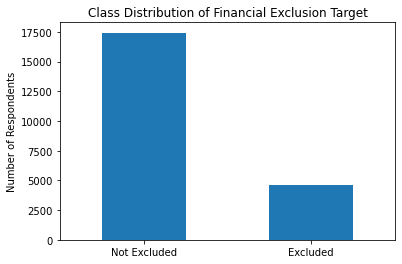

In [20]:
# Visualize class balance
import matplotlib.pyplot as plt

class_counts = df["financially_excluded"].value_counts()

plt.figure(figsize=(6,4))

class_counts.plot(kind="bar")

plt.xticks(
    [0, 1],
    ["Not Excluded", "Excluded"],
    rotation=0
)

plt.ylabel("Number of Respondents")
plt.title("Class Distribution of Financial Exclusion Target")

plt.show()

The target is imbalanced. Financially excluded respondents are the minority class.

This means accuracy alone will not be enough during modeling. Later notebooks should prioritize recall, precision, F1-score, ROC-AUC, and confusion matrix interpretation.

### **Target Engineering Columns**

Some variables are useful for defining or validating the target, but they should not be used as predictors.

If a model uses the same variables that define financial exclusion, it may produce artificially high performance.

In [8]:
target_engineering_cols = [
    "excluded_informal_banked2022"
]

#### ***Leakage Review***

Target leakage happens when the model sees information that directly reveals the answer.

In this project, leakage risk is high because financial exclusion is defined using financial access. Variables related to bank usage, SACCO usage, mobile money registration, insurance, formal access, informal access, loans, savings, and credit must be reviewed carefully.

In [9]:
leakage_keywords = [
    "banked", "excluded", "formal", "informal",
    "bank", "sacco", "insurance", "pension",
    "mobile", "money", "loan", "credit", "saving",
    "borrow"
]

potential_leakage_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

len(potential_leakage_cols)

104

In [10]:
potential_leakage_cols[:100]

['savings_usage',
 'savings_formal',
 'savings_informal',
 'savings_excluded',
 'loan_usage',
 'loan_formal',
 'loan_informal',
 'loan_formal_2',
 'loan_mbanking_2',
 'loan_fuliza_2',
 'loan_app_2',
 'savings_mbanking_2',
 'savings_mmoney_2',
 'savings_formal2',
 'tot_saving',
 'mobile',
 'bank_usage',
 'bank_usage1',
 'bank_usage3',
 'bank_usage2',
 'insurance_usage',
 'insurance_usage2',
 'insurance_usage1',
 'pension_usage',
 'pension_usage_2',
 'mobile_bank_usage',
 'mobile_money_usage',
 'digital_app_loan',
 'formal_digital_sav',
 'formal_non_digital_sav',
 'formal_digital_loan',
 'formal_non_digital_loan',
 'tot_formal_digit_loan_sav',
 'tot_formal_non_digit_loan_sav',
 'sacco_usage',
 'formal_prudential',
 'formal_non_prudential',
 'formal_registered',
 'formal',
 'formal_other',
 'informal',
 'Traditional_bank_users',
 'Commercial_Bank_users',
 'Post_bank_users',
 'Digital_credit',
 'mobile_access',
 'mobile_own',
 'formal_service_use',
 'formal_fullservice_use',
 'mobile_money

In [11]:
leakage_review = pd.DataFrame({
    "column": potential_leakage_cols,
    "reason": "keyword_match_financial_access",
    "decision": "review_before_modeling"
})

leakage_review.to_csv(
    ARTIFACTS_DIR / "02_leakage_review_columns.csv",
    index=False
)

In [12]:
definite_leakage_cols = [
    "excluded_informal_banked2022",
    "bank_usage",
    "mobile_money_usage",
    "formal",
    "informal",
    ...
]

### **Leakage Decision Framework**
Potential leakage variables were reviewed based on whether they directly reveal financial access status.

Variables directly describing:

bank account ownership
mobile money usage
SACCO participation
formal access
exclusion categories
are considered unsafe for the first structural-risk model because they strongly overlap with the target definition.

These variables may later be used in a separate operational inclusion model, but they are excluded from the structural-risk modeling dataset.

### **Administrative and ID Columns**

ID columns help identify records, interviews, households, or survey clusters. They are not useful for predicting future financial exclusion risk.

Using them can cause overfitting because the model may memorize records instead of learning general risk patterns.


In [13]:
id_like_keywords = [
    "id", "key", "serial", "cluster", "hhno", "interview"
]

id_like_cols = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in id_like_keywords)
]

id_like_cols

['Serial Number',
 'ClusterNo',
 'HHNo',
 'interview__key',
 'interview__id',
 'E1iD',
 'E1iiD',
 'E1iiiD',
 'E1viD',
 'E1viiD',
 'E1viiiD',
 'cluster_type',
 'Classification_A_Liquidity',
 'paidlate',
 'didnotdothis',
 'Classification_A_Liquidity_new']

In [14]:
admin_cols = [
    "Serial Number",
    "ClusterNo",
    "HHNo",
    "interview__key",
    "interview__id"
]

admin_cols = [col for col in admin_cols if col in df.columns]
admin_cols

['Serial Number', 'ClusterNo', 'HHNo', 'interview__key', 'interview__id']

### **Safe Predictor Selection**

This project begins with a structural-risk modeling dataset.

The goal is to predict financial exclusion risk using demographic, geographic, and socioeconomic characteristics instead of directly using financial service ownership variables.

This creates a cleaner and more policy-relevant model.

In [15]:
candidate_predictor_cols = [
    "County",   # geography
    "A9",       # rural/urban
    "A10i",     # sex
    "A19",      # age
    "A21",      # education completed
    "A22",      # marital status
    "adults"    # household adult composition
]

candidate_predictor_cols = [
    col for col in candidate_predictor_cols
    if col in df.columns
]

candidate_predictor_cols


['County', 'A9', 'A10i', 'A19', 'A21', 'A22', 'adults']

In [16]:
modeling_cols = candidate_predictor_cols + ["financially_excluded"]

model_df = df[modeling_cols].copy()

model_df.head()

,County,A9,A10i,A19,A21,A22,adults,financially_excluded
0,Trans Nzoia,Rural,Female,59,Completed technical training after secondary s...,Widowed,1 adult Household,0
1,Busia,Rural,Female,43,Completed technical training after secondary s...,Married/Living with partner,>1 adult Household,0
2,Machakos,Rural,Male,72,"""Some primary """,Divorced/separated,1 adult Household,1
3,Kisumu,Rural,Male,22,"""Primary completed""",Single/Never Married,>1 adult Household,0
4,Nyeri,Urban,Male,36,"""Primary completed""",Married/Living with partner,>1 adult Household,0


In [19]:
# Handle missing values
# Rows with missing target values would be removed if present.
model_df.isna().mean().mul(100).round(2).sort_values(ascending=False)

County                  0.0
A9                      0.0
A10i                    0.0
A19                     0.0
A21                     0.0
A22                     0.0
adults                  0.0
financially_excluded    0.0
dtype: float64


Since the selected structural-risk variables contained no missing values, no imputation was required for the first modeling dataset.
 A defensive dropna() step was included to ensure a fully complete modeling table.

### **Missing Value Strategy**

Survey datasets contain different types of missingness.

A missing value may indicate:
- the question was not applicable
- the respondent was skipped due to survey routing
- the respondent refused to answer
- the value was unknown

Because of this, missing values are not automatically treated as ordinary missing data.

For the first structural-risk modeling dataset, the selected core variables contain minimal missingness. However, later feature expansion notebooks may require:
- explicit missing-category encoding
- imputation
- structural missingness indicators
- variable-specific cleaning rules